In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

print("DOG BREED CLASSIFICATION - BASELINE CNN (KERAS)")



TensorFlow version: 2.10.0
GPU available: False
DOG BREED CLASSIFICATION - BASELINE CNN (KERAS)


In [3]:
with open('dataset_stats.json', 'r') as f:
    stats = json.load(f)

mean = np.array(stats['mean'])
std = np.array(stats['std'])
num_classes = stats['num_classes']
img_size = stats['img_size']
idx_to_breed = {int(k): v for k, v in stats['idx_to_breed'].items()}
class_weight_dict = {int(k): v for k, v in stats['class_weight_dict'].items()}

print(f"✓ Number of classes: {num_classes}")
print(f"✓ Image size: {img_size}x{img_size}")

# Load splits
train_df = pd.read_csv('train_split.csv')
val_df = pd.read_csv('val_split.csv')
test_df = pd.read_csv('test_split.csv')

print(f"✓ Train: {len(train_df)} images")
print(f"✓ Val: {len(val_df)} images")
print(f"✓ Test: {len(test_df)} images")

✓ Number of classes: 120
✓ Image size: 224x224
✓ Train: 7155 images
✓ Val: 1533 images
✓ Test: 1534 images


In [4]:
BASE_PATH = '../dog-breed-identification/dog-breed-identification/'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')

# Add file paths
train_df['filepath'] = train_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))
val_df['filepath'] = val_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))
test_df['filepath'] = test_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))

# Convert labels to strings
train_df['label_str'] = train_df['breed'].astype(str)
val_df['label_str'] = val_df['breed'].astype(str)
test_df['label_str'] = test_df['breed'].astype(str)

batch_size = 32

# Training data generator (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=lambda x: (x - mean) / std
)

# Validation/Test data generator (NO augmentation)
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: (x - mean) / std
)

# Create generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"✓ Batch size: {batch_size}")
print(f"✓ Train batches: {len(train_generator)}")
print(f"✓ Val batches: {len(val_generator)}")

Found 7155 validated image filenames belonging to 120 classes.
Found 1533 validated image filenames belonging to 120 classes.
Found 1534 validated image filenames belonging to 120 classes.
✓ Batch size: 32
✓ Train batches: 224
✓ Val batches: 48


In [6]:
def create_baseline_cnn(input_shape=(224, 224, 3), num_classes=15):
    """
    Simple CNN with 5 convolutional layers
    Architecture: Conv-BN-ReLU-Pool pattern with FC layers
    """
    
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 5
        layers.Conv2D(512, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Fully connected layers
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create model
model = create_baseline_cnn(input_shape=(img_size, img_size, 3), num_classes=num_classes)

# Count parameters
total_params = model.count_params()

print(f"\n✓ Model: Baseline CNN")
print(f"✓ Total parameters: {total_params:,}")

# Print model summary
print("\nModel Architecture:")
model.summary()


✓ Model: Baseline CNN
✓ Total parameters: 27,850,040

Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                               

In [10]:
print("\n[4] Compiling Model...")

# Hyperparameters (FIXED for fair comparison)
learning_rate = 0.001
num_epochs = 20

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✓ Optimizer: Adam")
print(f"✓ Learning rate: {learning_rate}")
print(f"✓ Loss function: Categorical Crossentropy")
print(f"✓ Batch size: {batch_size}")
print(f"✓ Epochs: {num_epochs}")


[4] Compiling Model...
✓ Optimizer: Adam
✓ Learning rate: 0.001
✓ Loss function: Categorical Crossentropy
✓ Batch size: 32
✓ Epochs: 20


In [11]:
print("\n[5] Setting Up Callbacks...")

callbacks = [
    # Save best model
    ModelCheckpoint(
        'baseline_cnn_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Early stopping (optional, but prevents overfitting)
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

print("✓ Callbacks configured:")
print("  - ModelCheckpoint (save best model)")
print("  - ReduceLROnPlateau (reduce LR on plateau)")
print("  - EarlyStopping (patience=15)")


[5] Setting Up Callbacks...
✓ Callbacks configured:
  - ModelCheckpoint (save best model)
  - ReduceLROnPlateau (reduce LR on plateau)
  - EarlyStopping (patience=15)


In [12]:
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=num_epochs,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Handle class imbalance
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("TRAINING COMPLETED!")
print("=" * 70)
print(f"Total Training Time: {training_time/60:.2f} minutes")

Epoch 1/20
224/224 [==============================] - ETA: 0s - loss: 4.7887 - accuracy: 0.0067
Epoch 1: val_accuracy improved from -inf to 0.00783, saving model to baseline_cnn_best.h5
224/224 [==============================] - 1028s 5s/step - loss: 4.7887 - accuracy: 0.0067 - val_loss: 4.7876 - val_accuracy: 0.0078 - lr: 0.0010
Epoch 2/20
224/224 [==============================] - ETA: 0s - loss: 4.7884 - accuracy: 0.0064
Epoch 2: val_accuracy improved from 0.00783 to 0.01044, saving model to baseline_cnn_best.h5
224/224 [==============================] - 488s 2s/step - loss: 4.7884 - accuracy: 0.0064 - val_loss: 4.7876 - val_accuracy: 0.0104 - lr: 0.0010
Epoch 3/20
224/224 [==============================] - ETA: 0s - loss: 4.7884 - accuracy: 0.0057
Epoch 3: val_accuracy did not improve from 0.01044
224/224 [==============================] - 402s 2s/step - loss: 4.7884 - accuracy: 0.0057 - val_loss: 4.7876 - val_accuracy: 0.0104 - lr: 0.0010
Epoch 4/20
224/224 [======================

In [13]:
history_df = pd.DataFrame({
    'epoch': range(1, len(history.history['loss']) + 1),
    'train_loss': history.history['loss'],
    'train_acc': [acc * 100 for acc in history.history['accuracy']],
    'val_loss': history.history['val_loss'],
    'val_acc': [acc * 100 for acc in history.history['val_accuracy']],
    'lr': history.history['lr']
})

history_df.to_csv('baseline_cnn_history.csv', index=False)
print("✓ Saved: baseline_cnn_history.csv")

# Find best epoch
best_epoch = history_df['val_acc'].idxmax() + 1
best_val_acc = history_df['val_acc'].max()

print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")

✓ Saved: baseline_cnn_history.csv
Best Validation Accuracy: 1.04% (Epoch 2)


In [14]:
model = keras.models.load_model('baseline_cnn_best.h5')
print("✓ Loaded best model")

# Evaluate
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
test_acc *= 100  # Convert to percentage

print(f"\nTest Set Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

✓ Loaded best model

Test Set Results:
  Test Loss: 4.7876
  Test Accuracy: 1.04%


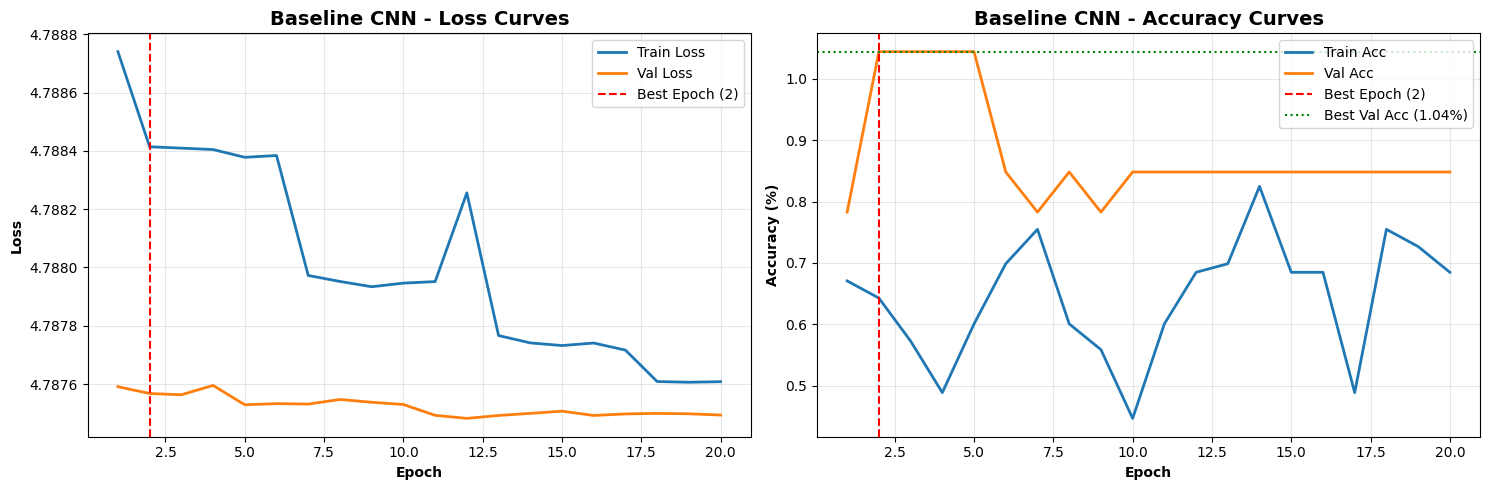

✓ Saved: baseline_cnn_training_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(history_df['epoch'], history_df['train_loss'], 
             label='Train Loss', linewidth=2)
axes[0].plot(history_df['epoch'], history_df['val_loss'], 
             label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Baseline CNN - Loss Curves', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(history_df['epoch'], history_df['train_acc'], 
             label='Train Acc', linewidth=2)
axes[1].plot(history_df['epoch'], history_df['val_acc'], 
             label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
axes[1].axhline(y=best_val_acc, color='green', linestyle=':', 
                label=f'Best Val Acc ({best_val_acc:.2f}%)')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('Baseline CNN - Accuracy Curves', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: baseline_cnn_training_curves.png")

In [16]:
print("BASELINE CNN SUMMARY")
print("=" * 70)

summary = {
    'model': 'Baseline CNN',
    'total_params': int(total_params),
    'trainable_params': int(total_params),
    'epochs_trained': len(history_df),
    'best_epoch': int(best_epoch),
    'best_val_acc': float(best_val_acc),
    'test_acc': float(test_acc),
    'training_time_minutes': float(training_time / 60),
    'final_train_acc': float(history_df['train_acc'].iloc[-1]),
    'final_val_acc': float(history_df['val_acc'].iloc[-1])
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Save summary
with open('baseline_cnn_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("\n✓ Saved: baseline_cnn_summary.json")

BASELINE CNN SUMMARY
  model: Baseline CNN
  total_params: 27850040
  trainable_params: 27850040
  epochs_trained: 20
  best_epoch: 2
  best_val_acc: 1.0437
  test_acc: 1.0430
  training_time_minutes: 140.7731
  final_train_acc: 0.6848
  final_val_acc: 0.8480

✓ Saved: baseline_cnn_summary.json
